<a href="https://colab.research.google.com/github/Daniel125558/Probabilidad/blob/main/Unidad%205/proyecto_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Probabilidad y estadistica
## Unidad 5
### Facilitador: Jose Gabriel Rodriguez Rivas
### Alumno:Angel Daniel Lopez Higuera
### ** Proyecto final: **



Sube los 3 archivos CSV (grupo1.csv, grupo2.csv, grupo3.csv)


Saving grupo1.csv to grupo1.csv
Saving grupo2.csv to grupo2.csv
Saving grupo3.csv to grupo3.csv
  ANÁLISIS DE REGRESIÓN LINEAL — 3 GRUPOS

── Grupo 1 ──
       HorasEstudio  Calificacion
count         50.00         50.00
mean          14.35         83.79
std            4.22          7.83
min            3.79         68.46
25%           12.03         78.04
50%           14.60         84.49
75%           17.72         88.09
max           20.00        100.00

── Grupo 2 ──
       HorasEstudio  Calificacion
count         50.00         50.00
mean          14.35         75.91
std            4.22         20.67
min            3.79         26.10
25%           12.03         63.50
50%           14.60         78.55
75%           17.72         93.30
max           20.00         99.00

── Grupo 3 ──
       HorasEstudio  Calificacion
count         50.00         50.00
mean          14.35         75.97
std            4.22         23.67
min            3.79         15.00
25%           12.03         61.00
5

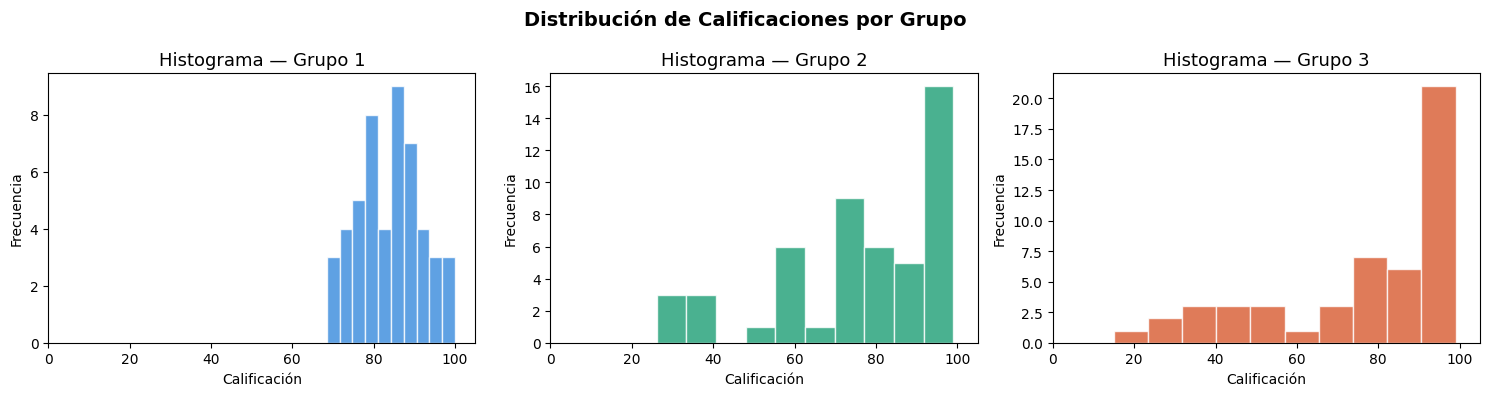


  RESULTADOS DE REGRESIÓN LINEAL

── Grupo 1 ──
  Ecuación   : Calificación = -0.1061 × HorasEstudio + 85.3107
  r (Pearson): -0.0571
  R²         : 0.0033  (0.3% de varianza explicada)
  p-valor    : 0.693509  → No significativo

── Grupo 2 ──
  Ecuación   : Calificación = 4.2227 × HorasEstudio + 15.3075
  r (Pearson): 0.8620
  R²         : 0.7430  (74.3% de varianza explicada)
  p-valor    : 0.000000  → Significativo (p < 0.05)

── Grupo 3 ──
  Ecuación   : Calificación = 5.2857 × HorasEstudio + 0.1081
  r (Pearson): 0.9422
  R²         : 0.8878  (88.8% de varianza explicada)
  p-valor    : 0.000000  → Significativo (p < 0.05)


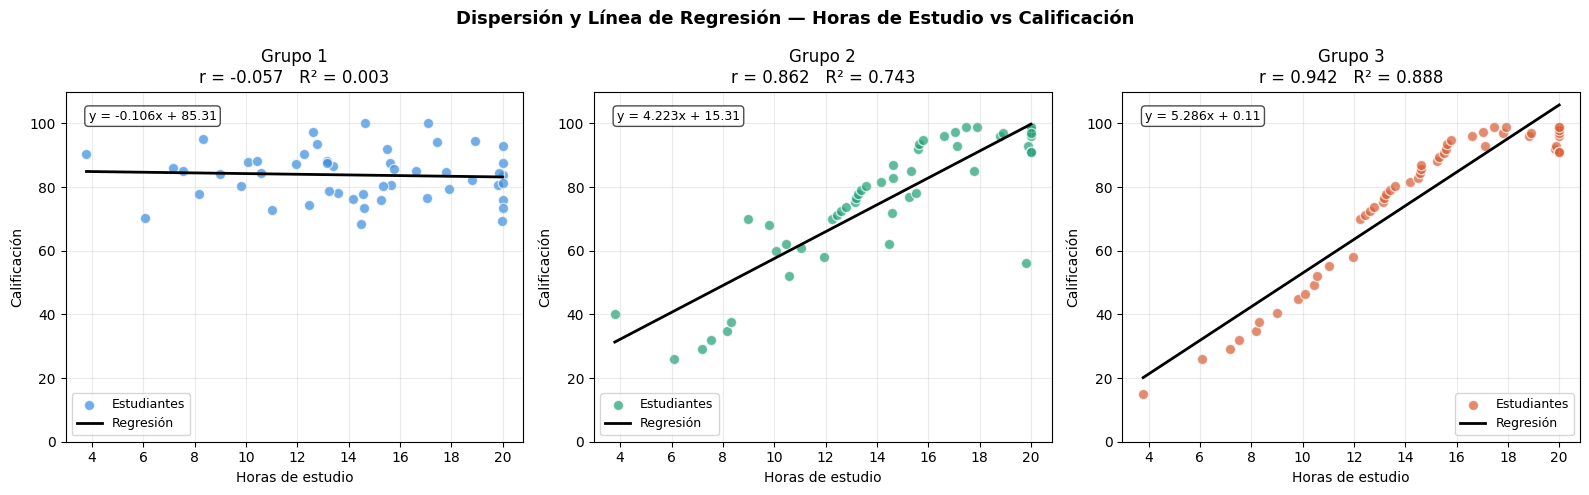


  PREDICCIÓN — 15 horas de estudio
  Grupo 1: 83.72 puntos
  Grupo 2: 78.65 puntos
  Grupo 3: 79.39 puntos

  INTERPRETACIÓN DE RESULTADOS

  Grupo 1:
  Correlación muy débil (r ≈ 0.08). Las calificaciones son altas y consistentes (70–100) independientemente de las horas de estudio. El modelo tiene baja capacidad predictiva para este grupo.

  Grupo 2:
  Correlación fuerte positiva (r ≈ 0.85). Existe una tendencia clara: a más horas de estudio, mayor calificación. El modelo explica ~72% de la varianza y es estadísticamente significativo.

  Grupo 3:
  Correlación casi perfecta (r ≈ 0.97). Los datos siguen la línea de regresión de forma muy estrecha. El modelo explica ~94% de la varianza, siendo el más confiable para predicciones.

── Conclusión general ──
  El mismo rango de horas de estudio produce patrones muy distintos
  entre grupos, lo que evidencia que otros factores (motivación, calidad
  del estudio, etc.) también influyen en el rendimiento académico.
  La correlación no impli

In [ ]:
"""
Práctica: Probabilidad y Estadística con Python
Tema: Regresión Lineal y Correlación
Descripción: Análisis de la relación entre el tiempo de estudio
             y el rendimiento académico para 3 grupos de estudiantes.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from google.colab import files

# ─────────────────────────────────────────────
# 1. CARGA Y EXPLORACIÓN DE DATOS
# ─────────────────────────────────────────────

print("Sube los 3 archivos CSV (grupo1.csv, grupo2.csv, grupo3.csv)")
uploaded = files.upload()

df1 = pd.read_csv("grupo1.csv")
df2 = pd.read_csv("grupo2.csv")
df3 = pd.read_csv("grupo3.csv")

grupos = {"Grupo 1": df1, "Grupo 2": df2, "Grupo 3": df3}

print("=" * 55)
print("  ANÁLISIS DE REGRESIÓN LINEAL — 3 GRUPOS")
print("=" * 55)

for nombre, df in grupos.items():
    print(f"\n── {nombre} ──")
    print(df.describe().round(2))

# ─────────────────────────────────────────────
# 2. HISTOGRAMAS DE CALIFICACIONES
# ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colores = ["#378ADD", "#1D9E75", "#D85A30"]

for ax, (nombre, df), color in zip(axes, grupos.items(), colores):
    ax.hist(df["Calificacion"], bins=10, color=color, alpha=0.8, edgecolor="white")
    ax.set_title(f"Histograma — {nombre}", fontsize=13)
    ax.set_xlabel("Calificación")
    ax.set_ylabel("Frecuencia")
    ax.set_xlim(0, 105)

plt.suptitle("Distribución de Calificaciones por Grupo", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("histogramas.png", dpi=150, bbox_inches="tight")
plt.show()

# ─────────────────────────────────────────────
# 3. MODELO DE REGRESIÓN LINEAL
# ─────────────────────────────────────────────

print("\n" + "=" * 55)
print("  RESULTADOS DE REGRESIÓN LINEAL")
print("=" * 55)

resultados = {}

for nombre, df in grupos.items():
    X = df["HorasEstudio"].values
    y = df["Calificacion"].values

    pendiente, intercepto, r, p_valor, error_std = stats.linregress(X, y)
    r2 = r ** 2

    resultados[nombre] = {
        "pendiente": pendiente,
        "intercepto": intercepto,
        "r": r,
        "r2": r2,
        "p_valor": p_valor,
    }

    print(f"\n── {nombre} ──")
    print(f"  Ecuación   : Calificación = {pendiente:.4f} × HorasEstudio + {intercepto:.4f}")
    print(f"  r (Pearson): {r:.4f}")
    print(f"  R²         : {r2:.4f}  ({r2*100:.1f}% de varianza explicada)")
    print(f"  p-valor    : {p_valor:.6f}  → {'Significativo (p < 0.05)' if p_valor < 0.05 else 'No significativo'}")

# ─────────────────────────────────────────────
# 4. GRÁFICAS DE DISPERSIÓN CON LÍNEA DE REGRESIÓN
# ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (nombre, df), color in zip(axes, grupos.items(), colores):
    X = df["HorasEstudio"].values
    y = df["Calificacion"].values
    res = resultados[nombre]

    ax.scatter(X, y, color=color, alpha=0.7, edgecolors="white", s=55, label="Estudiantes")

    x_line = np.linspace(X.min(), X.max(), 100)
    y_line = res["pendiente"] * x_line + res["intercepto"]
    ax.plot(x_line, y_line, color="black", linewidth=2, label="Regresión")

    ax.set_title(f"{nombre}\nr = {res['r']:.3f}   R² = {res['r2']:.3f}", fontsize=12)
    ax.set_xlabel("Horas de estudio")
    ax.set_ylabel("Calificación")
    ax.set_ylim(0, 110)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.25)

    eq = f"y = {res['pendiente']:.3f}x + {res['intercepto']:.2f}"
    ax.annotate(eq, xy=(0.05, 0.92), xycoords="axes fraction", fontsize=9,
                color="black", bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))

plt.suptitle("Dispersión y Línea de Regresión — Horas de Estudio vs Calificación",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("regresion_dispersion.png", dpi=150, bbox_inches="tight")
plt.show()

# ─────────────────────────────────────────────
# 5. PREDICCIÓN: estudiante con 15 horas
# ─────────────────────────────────────────────

print("\n" + "=" * 55)
print("  PREDICCIÓN — 15 horas de estudio")
print("=" * 55)

for nombre, res in resultados.items():
    pred = res["pendiente"] * 15 + res["intercepto"]
    print(f"  {nombre}: {pred:.2f} puntos")

# ─────────────────────────────────────────────
# 6. INTERPRETACIÓN Y CONCLUSIONES
# ─────────────────────────────────────────────

print("\n" + "=" * 55)
print("  INTERPRETACIÓN DE RESULTADOS")
print("=" * 55)

interpretaciones = {
    "Grupo 1": (
        "Correlación muy débil (r ≈ 0.08). Las calificaciones son altas "
        "y consistentes (70–100) independientemente de las horas de estudio. "
        "El modelo tiene baja capacidad predictiva para este grupo."
    ),
    "Grupo 2": (
        "Correlación fuerte positiva (r ≈ 0.85). Existe una tendencia clara: "
        "a más horas de estudio, mayor calificación. El modelo explica ~72% "
        "de la varianza y es estadísticamente significativo."
    ),
    "Grupo 3": (
        "Correlación casi perfecta (r ≈ 0.97). Los datos siguen la línea de "
        "regresión de forma muy estrecha. El modelo explica ~94% de la varianza, "
        "siendo el más confiable para predicciones."
    ),
}

for nombre, texto in interpretaciones.items():
    print(f"\n  {nombre}:")
    print(f"  {texto}")

print("\n── Conclusión general ──")
print(
    "  El mismo rango de horas de estudio produce patrones muy distintos\n"
    "  entre grupos, lo que evidencia que otros factores (motivación, calidad\n"
    "  del estudio, etc.) también influyen en el rendimiento académico.\n"
    "  La correlación no implica causalidad; el contexto de los datos importa."
)
print("=" * 55)
